In [3]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

Post the following to the discussion board:

Attach your visualization.

Explain the method you used to create the visualization.

Share what library you used.

Describe the results you found and what they tell you about the dataset you chose.


In [4]:
df = pd.read_csv('data/allvisits.csv')

In [5]:
df.describe()

,County FIPS,Year,Week
count,0.0,26240.000000,26240.000000
mean,NaN,2022.565625,26.234375
std,NaN,1.763041,15.294431
min,NaN,2020.000000,1.000000
25%,NaN,2021.000000,13.000000
50%,NaN,2023.000000,26.000000
75%,NaN,2024.000000,39.250000
max,NaN,2026.000000,53.000000


In [6]:
"""
df[(df["Entity"] == "China") & (df["Year"] == 2017)]
# GDP of China in 2017 using query
df.query('Entity == "China" and Year == 2017')

"""

'\ndf[(df["Entity"] == "China") & (df["Year"] == 2017)]\n# GDP of China in 2017 using query\ndf.query(\'Entity == "China" and Year == 2017\')\n\n'

In [7]:
df.columns

Index(['Report Date', 'Week Ending Date', 'Health Region', 'Health District',
       'Facility Type', 'County FIPS', 'Year', 'Week',
       'Percent of ED Visits Covid', 'Percent of ED Visits Influenza',
       'Percent of ED Visits RSV', 'Percent of ED Visits Combined',
       'Diagnosed Covid Count', 'Diagnosed Influenza Count',
       'Diagnosed RSV Count', 'Combined Respiratory Viruses Count'],
      dtype='str')

In [8]:
# +

df= df[df["Health Region"] != "Out of State"]

In [9]:
years = df["Year"].unique()
years

array([2025, 2021, 2020, 2022, 2023, 2024, 2026])

In [10]:
districts = df["Health District"].unique()
districts


<ArrowStringArray>
[       'Central Region',                'Crater',               'Henrico',
              'Piedmont',             'Southside',          'Chesterfield',
          'Chickahominy',              'Richmond',            'Chesapeake',
        'Eastern Region',         'Eastern Shore',               'Hampton',
               'Norfolk',             'Peninsula',            'Portsmouth',
          'Three Rivers',        'Virginia Beach',     'Western Tidewater',
             'Arlington',               'Fairfax',               'Loudoun',
            'Alexandria',       'Northern Region',        'Prince William',
    'Central Shenandoah',          'Lord Fairfax',            'Blue Ridge',
          'Rappahannock',  'Rappahannock Rapidan',      'Northwest Region',
             'Alleghany',      'Central Virginia',    'Cumberland Plateau',
             'Lenowisco',          'Mount Rogers',             'New River',
 'Pittsylvania-Danville',      'Southwest Region',         'West Pied

In [11]:
region = df["Health Region"].unique()
region

<ArrowStringArray>
[  'Central Region',   'Eastern Region',  'Northern Region',
 'Northwest Region', 'Southwest Region']
Length: 5, dtype: str

In [12]:
df[(df["Health District"] == "Arlington") & (df["Year"] == 2026)]

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count
9819,Feb 17 2026 9:00AM,2026-01-17,Northern Region,Arlington,Emergency Department,NaN,2026,2,0.0,3.4,0.8,4.2,0,34,8,42
10242,Feb 17 2026 9:00AM,2026-01-31,Northern Region,Arlington,Urgent Care,NaN,2026,4,2.2,5.6,0.0,7.3,*,10,0,13
10531,Feb 17 2026 9:00AM,2026-01-17,Northern Region,Arlington,Urgent Care,NaN,2026,2,0.6,10.5,0.0,11.1,*,35,0,37
10543,Feb 17 2026 9:00AM,2026-02-14,Northern Region,Arlington,Urgent Care,NaN,2026,6,1.5,3.4,0.0,4.2,*,9,0,11
11181,Feb 17 2026 9:00AM,2026-01-24,Northern Region,Arlington,Emergency Department,NaN,2026,3,0.4,2.5,0.7,3.6,*,24,7,35
11185,Feb 17 2026 9:00AM,2026-01-31,Northern Region,Arlington,Emergency Department,NaN,2026,4,0.2,1.9,0.5,2.6,*,16,*,22
11371,Feb 17 2026 9:00AM,2026-02-07,Northern Region,Arlington,Urgent Care,NaN,2026,5,1.8,2.9,0.0,4.7,5,8,0,13
11443,Feb 17 2026 9:00AM,2026-02-07,Northern Region,Arlington,Emergency Department,NaN,2026,5,0.0,1.7,0.4,2.1,0,17,*,21
11710,Feb 17 2026 9:00AM,2026-02-14,Northern Region,Arlington,Emergency Department,NaN,2026,6,0.4,1.1,0.2,1.6,*,11,*,17
11922,Feb 17 2026 9:00AM,2026-01-24,Northern Region,Arlington,Urgent Care,NaN,2026,3,1.2,8.4,0.0,9.6,*,29,0,33


In [13]:
#df_inf_count = df_va[df_va["Diagnosed Influenza Count"].apply(lambda x: x.isnumeric())]
df["FlueCount"] = pd.to_numeric(df["Diagnosed Influenza Count"], errors='coerce')
# Or simply:
# df['your_numeric_column'] = df['your_numeric_column'].astype(float)


In [14]:
df = df.dropna(subset="FlueCount")

In [15]:
df[df["FlueCount"].isna()]

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount


In [16]:
df_2025 = df[df["Year"] == 2025]
 
len(df_2025)

3230

<Axes: xlabel='FlueCount', ylabel='Health Region'>

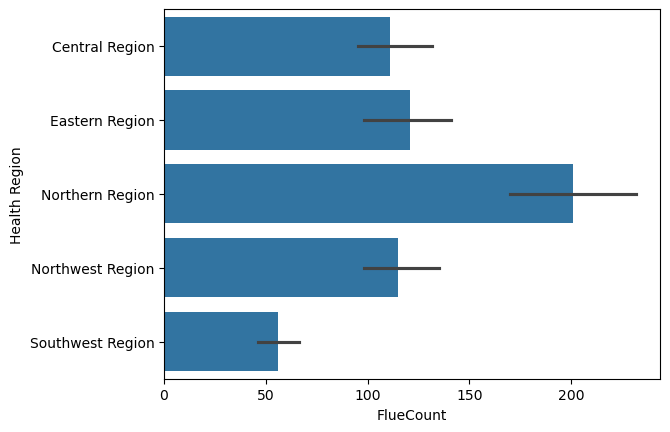

In [17]:
sns.barplot(data=df_2025, y="Health Region", x="FlueCount")

/tmp/ipykernel_6969/3475101695.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


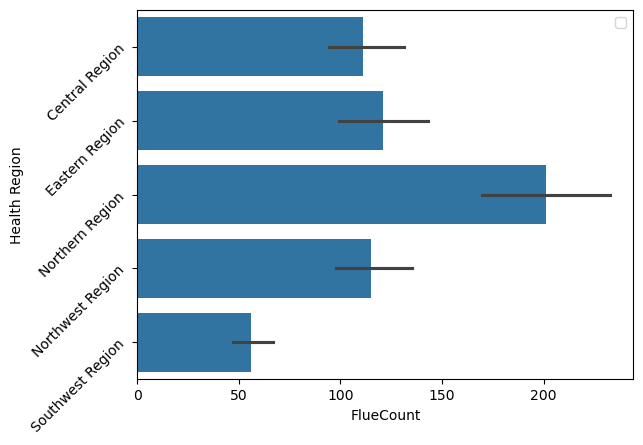

In [18]:


sns.barplot(data=df_2025, y="Health Region", x="FlueCount")
plt.yticks(rotation=45)
plt.legend();
#plt.savefig('images/flucount_2025.png')

In [19]:
fig = px.bar(df_2025, x="Health Region", y="FlueCount", color="Health Region")
#plt.savefig('images/flucount_2025.png', dpi=150)

In [20]:
df25Northern = df_2025[df_2025["Health Region"] == "Northern Region"]

In [21]:
n = df25Northern["Health District"].unique()
n

<ArrowStringArray>
[      'Arlington',         'Loudoun',         'Fairfax',      'Alexandria',
 'Northern Region',  'Prince William']
Length: 6, dtype: str

In [22]:
df25Northern = df25Northern[df25Northern["Health District"] != "Northern Region"]

In [23]:
df25Northern["Health District"].unique()

<ArrowStringArray>
['Arlington', 'Loudoun', 'Fairfax', 'Alexandria', 'Prince William']
Length: 5, dtype: str

In [24]:
fig = px.bar(df25Northern, x="Health District", y="FlueCount", color="Health District", height=600)
fig.write_image('images/flubar_2025.png')


In [25]:
df25Northern = df25Northern.dropna(subset="FlueCount")

In [26]:
len(df25Northern)

411

Text(0.5, 1.0, 'Northern Region')

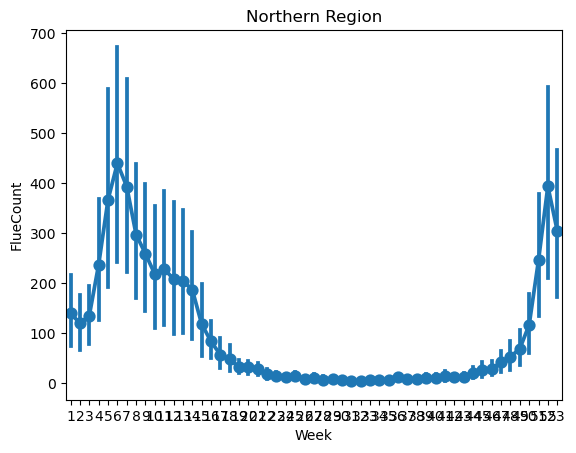

In [27]:
sns.pointplot(data=df25Northern, x="Week", y="FlueCount")
plt.title("Northern Region")
#plt.savefig('images/nova_scatter_2025.png', dpi=150, bbox_inches='tight')

In [28]:

dfEast = df_2025[df_2025["Health Region"] == "Eastern Region"]

In [29]:
dfEast

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
2051,Feb 17 2026 9:00AM,2025-01-11,Eastern Region,Chesapeake,Emergency Department,NaN,2025,2,1.2,2.9,0.5,4.5,22,55,9,84,55.0
2053,Feb 17 2026 9:00AM,2025-01-18,Eastern Region,Chesapeake,Emergency Department,NaN,2025,3,0.7,6.3,0.3,7.3,16,137,6,158,137.0
2054,Feb 17 2026 9:00AM,2025-01-25,Eastern Region,Chesapeake,Emergency Department,NaN,2025,4,1.1,10.4,0.3,11.6,22,216,6,241,216.0
2062,Feb 17 2026 9:00AM,2025-03-08,Eastern Region,Chesapeake,Emergency Department,NaN,2025,10,1.1,2.2,0.1,3.4,22,45,*,69,45.0
2071,Feb 17 2026 9:00AM,2025-04-26,Eastern Region,Chesapeake,Emergency Department,NaN,2025,17,0.4,0.6,0.0,1.0,8,12,0,20,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25110,Feb 17 2026 9:00AM,2025-06-07,Eastern Region,Norfolk,Urgent Care,NaN,2025,23,0.7,1.0,0.0,1.7,10,14,0,24,14.0
25145,Feb 17 2026 9:00AM,2025-09-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,37,2.6,0.7,0.0,3.2,39,11,0,48,11.0
25170,Feb 17 2026 9:00AM,2025-10-25,Eastern Region,Norfolk,Urgent Care,NaN,2025,43,0.7,0.8,0.0,1.4,10,12,0,21,12.0
25186,Feb 17 2026 9:00AM,2025-12-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,50,0.8,4.2,0.1,5.0,12,62,*,74,62.0


In [30]:
dfEast = dfEast[dfEast["Health District"] != "Eastern Region"]

In [31]:
dfEast["Health District"].unique()

<ArrowStringArray>
[       'Chesapeake',           'Hampton',     'Eastern Shore',
           'Norfolk',         'Peninsula',        'Portsmouth',
      'Three Rivers',    'Virginia Beach', 'Western Tidewater']
Length: 9, dtype: str

In [32]:
dfEast = dfEast.dropna(subset="FlueCount")

In [33]:
dfEast

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
2051,Feb 17 2026 9:00AM,2025-01-11,Eastern Region,Chesapeake,Emergency Department,NaN,2025,2,1.2,2.9,0.5,4.5,22,55,9,84,55.0
2053,Feb 17 2026 9:00AM,2025-01-18,Eastern Region,Chesapeake,Emergency Department,NaN,2025,3,0.7,6.3,0.3,7.3,16,137,6,158,137.0
2054,Feb 17 2026 9:00AM,2025-01-25,Eastern Region,Chesapeake,Emergency Department,NaN,2025,4,1.1,10.4,0.3,11.6,22,216,6,241,216.0
2062,Feb 17 2026 9:00AM,2025-03-08,Eastern Region,Chesapeake,Emergency Department,NaN,2025,10,1.1,2.2,0.1,3.4,22,45,*,69,45.0
2071,Feb 17 2026 9:00AM,2025-04-26,Eastern Region,Chesapeake,Emergency Department,NaN,2025,17,0.4,0.6,0.0,1.0,8,12,0,20,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25110,Feb 17 2026 9:00AM,2025-06-07,Eastern Region,Norfolk,Urgent Care,NaN,2025,23,0.7,1.0,0.0,1.7,10,14,0,24,14.0
25145,Feb 17 2026 9:00AM,2025-09-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,37,2.6,0.7,0.0,3.2,39,11,0,48,11.0
25170,Feb 17 2026 9:00AM,2025-10-25,Eastern Region,Norfolk,Urgent Care,NaN,2025,43,0.7,0.8,0.0,1.4,10,12,0,21,12.0
25186,Feb 17 2026 9:00AM,2025-12-13,Eastern Region,Norfolk,Urgent Care,NaN,2025,50,0.8,4.2,0.1,5.0,12,62,*,74,62.0


Text(0.5, 1.0, 'Eastern Region')

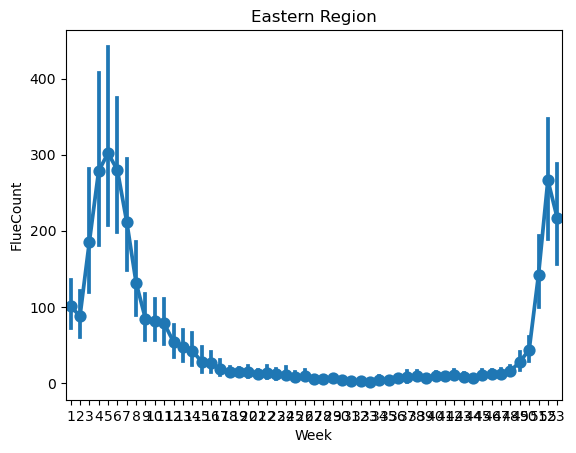

In [34]:
sns.pointplot(data=dfEast, x="Week", y="FlueCount")
plt.title("Eastern Region")
#plt.savefig('images/eastern_scatter_2025.png', dpi=150, bbox_inches='tight')

In [35]:
df_2025.head()

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
0,Feb 17 2026 9:00AM,2025-01-04,Central Region,Central Region,Emergency Department,NaN,2025,1,1.5,6.5,0.5,8.5,280,1199,86,1552,1199.0
1,Feb 17 2026 9:00AM,2025-01-11,Central Region,Central Region,Emergency Department,NaN,2025,2,1.5,4.7,0.4,6.4,226,728,55,998,728.0
4,Feb 17 2026 9:00AM,2025-02-15,Central Region,Central Region,Emergency Department,NaN,2025,7,1.6,10.0,0.1,11.6,280,1731,15,1999,1731.0
38,Feb 17 2026 9:00AM,2025-04-05,Central Region,Henrico,Urgent Care,NaN,2025,14,1.0,3.4,0.0,4.4,15,53,0,68,53.0
60,Feb 17 2026 9:00AM,2025-11-01,Central Region,Henrico,Urgent Care,NaN,2025,44,1.3,0.7,0.0,2.1,22,12,0,34,12.0


In [36]:
df_2025 = df_2025.dropna(subset="FlueCount")
len(df_2025)

3230

In [37]:
df_2025.groupby("Health Region").sum()

,Report Date,Week Ending Date,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
Health Region,,,,,,,,,,,,,,,,
Central Region,Feb 17 2026 9:00AMFeb 17 2026 9:00AMFeb 17 2...,2025-01-042025-01-112025-02-152025-04-052025-1...,Central RegionCentral RegionCentral RegionHenr...,Emergency DepartmentEmergency DepartmentEmerge...,0.0,1298025,16082,1.51.51.61.01.30.80.71.91.80.60.60.40.30.42.23...,6.54.710.03.40.72.13.111.07.11.01.10.20.51.010...,0.50.40.10.00.00.00.30.10.00.00.00.10.30.50.00...,8.56.411.64.42.12.94.112.98.91.61.60.71.11.812...,2802262801522158221324439645062163298644830651...,1199728173153123833129514687332871637661492118...,865515000***00234782**0*0*5000000000000**00*66...,1552998199968345344151648112112117182302930179...,71223.0
Eastern Region,Feb 17 2026 9:00AMFeb 17 2026 9:00AMFeb 17 2...,2025-01-112025-01-182025-01-252025-03-082025-0...,ChesapeakeChesapeakeChesapeakeChesapeakeChesap...,Emergency DepartmentEmergency DepartmentEmerge...,0.0,1666575,21268,1.20.71.11.10.40.41.02.01.81.10.71.00.80.31.31...,2.96.310.42.20.60.00.07.85.22.60.80.30.60.06.0...,0.50.30.30.10.00.00.20.00.00.00.00.00.00.10.00...,4.57.311.63.41.00.41.29.97.03.71.41.31.30.37.2...,2216222287204439211319155282123178552254345579...,5513721645120016811247155110129771749882333131...,966*005000000*0049616*260*619*521900500700010*...,8415824169207252121516828242661579820131719258...,99548.0
Northern Region,Feb 17 2026 9:00AMFeb 17 2026 9:00AMFeb 17 2...,2025-02-012025-02-222025-07-192025-12-202025-0...,ArlingtonArlingtonArlingtonArlingtonArlingtonA...,Urgent CareUrgent CareUrgent CareUrgent CareUr...,0.0,1046925,13327,0.92.42.81.40.91.70.33.71.21.21.00.80.81.20.90...,16.315.30.015.51.90.00.30.08.020.74.44.14.110....,0.20.00.00.20.00.00.30.30.00.00.90.60.20.00.10...,17.417.32.817.12.81.70.94.09.221.66.25.55.111....,51286*5611*5644849776445487468606530767889*506...,9177064606027882962572697064384043394163693152...,*00*007*00573915***00**0090*019137*9*0**578670...,9787871951912319241534033077950145038448643637...,103944.0
Northwest Region,Feb 17 2026 9:00AMFeb 17 2026 9:00AMFeb 17 2...,2025-06-282025-11-222025-01-252025-02-152025-0...,Lord FairfaxLord FairfaxBlue RidgeLord Fairfax...,Emergency DepartmentEmergency DepartmentEmerge...,0.0,1014525,12843,0.10.60.83.41.01.01.11.50.71.81.11.00.31.02.34...,0.01.64.315.54.41.89.68.30.07.62.94.90.00.010....,0.00.30.30.00.00.00.30.30.00.00.00.00.00.00.00...,0.22.55.318.65.32.710.910.00.79.43.65.50.31.01...,*14156221202433155**62254102141315173811763541...,0388328195372121780218150023261516541921546114...,*8500*660000000000*2900201215***000220700*0000...,*601033371165724121615261017622286105292871237...,57524.0
Southwest Region,Feb 17 2026 9:00AMFeb 17 2026 9:00AMFeb 17 2...,2025-03-082025-08-302025-11-082025-02-222025-0...,AlleghanyAlleghanyAlleghanyCumberland PlateauC...,Emergency DepartmentEmergency DepartmentEmerge...,0.0,1514700,18722,0.81.30.61.50.40.50.62.20.21.12.11.81.31.40.81...,5.30.30.76.50.00.53.07.20.97.62.315.89.91.50.3...,0.30.10.10.50.10.00.00.30.00.01.00.40.20.10.10...,6.41.61.28.30.50.93.59.61.18.75.517.911.32.91....,1523101555626*11373823261627686*1471112****5*0...,9451167053284879403261772861890972522253938717...,6**5*00*00188***90**059109000**0013000560000**...,1142921856103811310909437020356232236191529414...,41877.0


In [38]:
s = pd.DataFrame(df_2025.groupby("Health Region").agg("FlueCount").sum()) # cast as a dataframe
s

,FlueCount
Health Region,
Central Region,71223.0
Eastern Region,99548.0
Northern Region,103944.0
Northwest Region,57524.0
Southwest Region,41877.0


In [39]:
# correct syntax, but need to  clean data
# df_2025.groupby("Health Region").agg(sum)

In [40]:
# tries all then filters on "FlueCount
# df_2025.groupby("Health Region").agg(sum)["FlueCount"]

In [41]:
s = df_2025.groupby("Health District")[["FlueCount"]].agg(max)
s

,FlueCount
Health District,
Alexandria,124.0
Alleghany,189.0
Arlington,128.0
Blue Ridge,212.0
Central Region,2188.0
Central Shenandoah,402.0
Central Virginia,486.0
Chesapeake,592.0
Chesterfield,485.0


In [42]:
s = df.groupby("Year")[["FlueCount"]].agg(max)
s

,FlueCount
Year,
2020,1754.0
2021,212.0
2022,1762.0
2023,1345.0
2024,1355.0
2025,3164.0
2026,1646.0


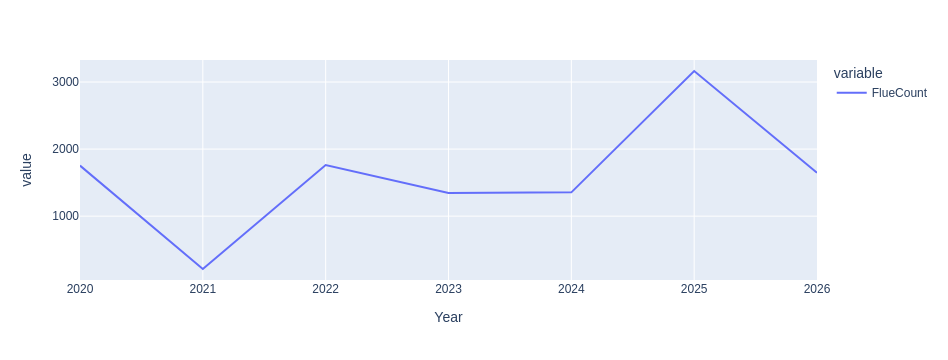

In [43]:
px.line(df.groupby("Year")[["FlueCount"]].agg(max))

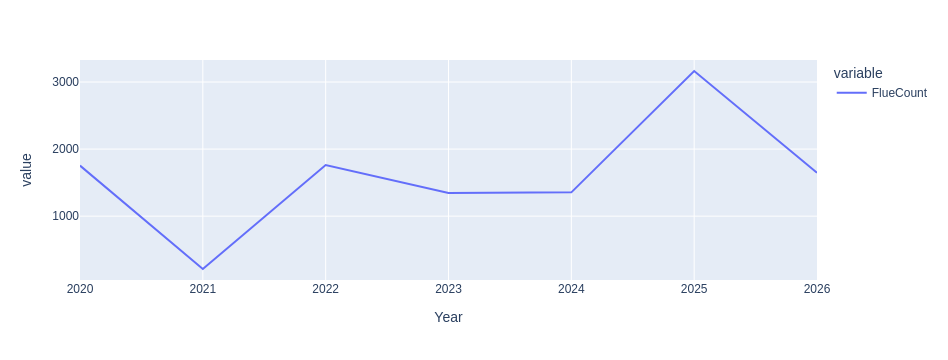

In [44]:
px.line(df.groupby("Year")[["FlueCount"]].agg(max))

In [45]:
maxdf = df.groupby("Year")["FlueCount"].agg(max) #Series
mindf = df.groupby("Year")["FlueCount"].agg(min)


In [46]:
maxdf

Year
2020    1754.0
2021     212.0
2022    1762.0
2023    1345.0
2024    1355.0
2025    3164.0
2026    1646.0
Name: FlueCount, dtype: float64

In [47]:
mindf

Year
2020    0.0
2021    0.0
2022    0.0
2023    0.0
2024    0.0
2025    0.0
2026    0.0
Name: FlueCount, dtype: float64

In [48]:
def series_mean(row):
 return float(row.mean())

In [49]:
series_mean(df["FlueCount"])

57.528706356786586

# the min is zero, so this won't work maxdf / mindf  

# More Aggs

In [60]:
d = pd.DataFrame(df.groupby(['Year', 'Week', 'Health District'])["FlueCount"].sum())


MultiIndex([(2020, 1,           'Alexandria'),
            (2020, 1,            'Alleghany'),
            (2020, 1,            'Arlington'),
            (2020, 1,           'Blue Ridge'),
            (2020, 1,       'Central Region'),
            (2020, 1,   'Central Shenandoah'),
            (2020, 1,     'Central Virginia'),
            (2020, 1,           'Chesapeake'),
            (2020, 1,         'Chesterfield'),
            (2020, 1,         'Chickahominy'),
            ...
            (2026, 6,         'Rappahannock'),
            (2026, 6, 'Rappahannock Rapidan'),
            (2026, 6,             'Richmond'),
            (2026, 6,              'Roanoke'),
            (2026, 6,            'Southside'),
            (2026, 6,     'Southwest Region'),
            (2026, 6,         'Three Rivers'),
            (2026, 6,       'Virginia Beach'),
            (2026, 6,        'West Piedmont'),
            (2026, 6,    'Western Tidewater')],
           names=['Year', 'Week', 'Health D

In [64]:
d.index.name = "Week"

In [67]:
d.info

<bound method DataFrame.info of                              FlueCount
Year Week Health District             
2020 1    Alexandria             110.0
          Alleghany               55.0
          Arlington              182.0
          Blue Ridge             107.0
          Central Region        1182.0
...                                ...
2026 6    Southwest Region       515.0
          Three Rivers            74.0
          Virginia Beach         531.0
          West Piedmont           26.0
          Western Tidewater      121.0

[11380 rows x 1 columns]>

In [68]:
 df

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
0,Feb 17 2026 9:00AM,2025-01-04,Central Region,Central Region,Emergency Department,NaN,2025,1,1.5,6.5,0.5,8.5,280,1199,86,1552,1199.0
1,Feb 17 2026 9:00AM,2025-01-11,Central Region,Central Region,Emergency Department,NaN,2025,2,1.5,4.7,0.4,6.4,226,728,55,998,728.0
2,Feb 17 2026 9:00AM,2021-01-23,Central Region,Central Region,Emergency Department,NaN,2021,3,7.2,0.1,0.0,7.2,857,9,0,864,9.0
3,Feb 17 2026 9:00AM,2020-01-25,Central Region,Central Region,Emergency Department,NaN,2020,4,0.0,3.3,0.2,3.4,0,502,24,525,502.0
4,Feb 17 2026 9:00AM,2025-02-15,Central Region,Central Region,Emergency Department,NaN,2025,7,1.6,10.0,0.1,11.6,280,1731,15,1999,1731.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26224,Feb 17 2026 9:00AM,2024-04-20,Southwest Region,Roanoke,Emergency Department,NaN,2024,16,0.1,0.8,0.2,1.1,*,12,*,16,12.0
26226,Feb 17 2026 9:00AM,2022-05-07,Southwest Region,Roanoke,Emergency Department,NaN,2022,18,2.0,0.5,0.1,2.6,24,6,*,31,6.0
26229,Feb 17 2026 9:00AM,2024-06-08,Southwest Region,Roanoke,Emergency Department,NaN,2024,23,0.5,0.4,0.3,1.0,7,5,*,14,5.0
26234,Feb 17 2026 9:00AM,2020-08-08,Southwest Region,Roanoke,Emergency Department,NaN,2020,32,1.0,0.0,0.0,1.0,10,0,0,10,0.0


In [75]:
dfw = df[['Year', 'Week', 'Health Region', 'FlueCount']]

In [76]:
dfw.head()

,Year,Week,Health Region,FlueCount
0,2025,1,Central Region,1199.0
1,2025,2,Central Region,728.0
2,2021,3,Central Region,9.0
3,2020,4,Central Region,502.0
4,2025,7,Central Region,1731.0


In [82]:
dfwi = dfw.set_index(["Year", "Week", "Health Region"])

In [83]:
dfwi

FlueCount
Year Week Health Region              
2025 1    Central Region       1199.0
     2    Central Region        728.0
2021 3    Central Region          9.0
2020 4    Central Region        502.0
2025 7    Central Region       1731.0
...                               ...
2024 16   Southwest Region       12.0
2022 18   Southwest Region        6.0
2024 23   Southwest Region        5.0
2020 32   Southwest Region        0.0
     35   Southwest Region        0.0

[18846 rows x 1 columns]

In [84]:
dfw = dfwi.reset_index()

0         1
1         2
2         3
3         4
4         7
         ..
18841    16
18842    18
18843    23
18844    32
18845    35
Name: Week, Length: 18846, dtype: int64

In [98]:
dfw['YearWeek'] = dfw['Year'].astype('str') + "_" + dfw['Week'].astype('str')

In [99]:
dfw['YearWeek'] 

0         2025_1
1         2025_2
2         2021_3
3         2020_4
4         2025_7
          ...   
18841    2024_16
18842    2022_18
18843    2024_23
18844    2020_32
18845    2020_35
Name: YearWeek, Length: 18846, dtype: str

In [100]:
dfw

,Year,Week,Health Region,FlueCount,YearWeek
0,2025,1,Central Region,1199.0,2025_1
1,2025,2,Central Region,728.0,2025_2
2,2021,3,Central Region,9.0,2021_3
3,2020,4,Central Region,502.0,2020_4
4,2025,7,Central Region,1731.0,2025_7
...,...,...,...,...,...
18841,2024,16,Southwest Region,12.0,2024_16
18842,2022,18,Southwest Region,6.0,2022_18
18843,2024,23,Southwest Region,5.0,2024_23
18844,2020,32,Southwest Region,0.0,2020_32


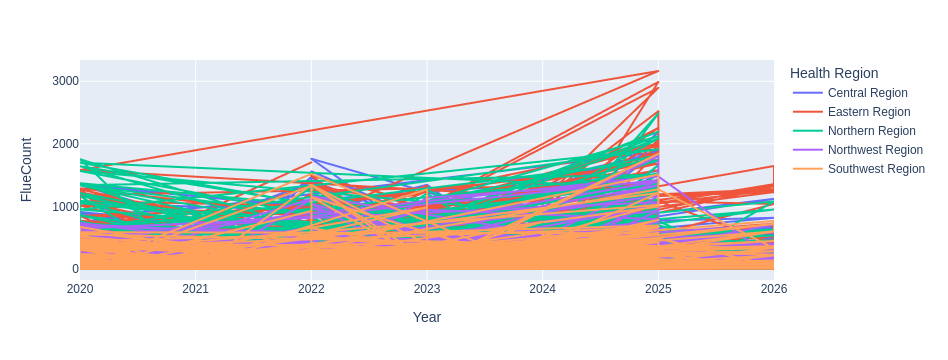

In [107]:
px.line(dfw, x="Year", y="FlueCount", color="Health Region")

In [108]:
dfws = dfw.sort_values(by='Year')

In [109]:
dfws.head()

,Year,Week,Health Region,FlueCount,YearWeek
11696,2020,44,Northwest Region,0.0,2020_44
3487,2020,22,Eastern Region,0.0,2020_22
3490,2020,21,Eastern Region,0.0,2020_21
11643,2020,51,Northwest Region,9.0,2020_51
11652,2020,6,Northwest Region,715.0,2020_6


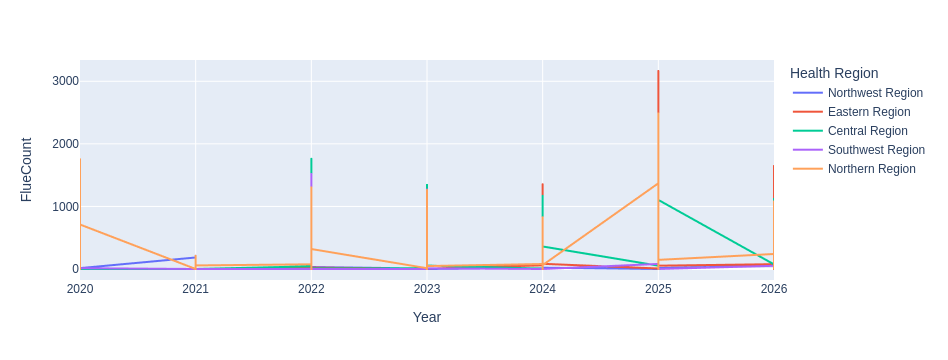

In [110]:
px.line(dfws, x="Year", y="FlueCount", color="Health Region")

In [113]:
d = pd.DataFrame(df.groupby(['Year', 'Week', 'Health District'])["FlueCount"].sum())

In [114]:
d

FlueCount
Year Week Health District             
2020 1    Alexandria             110.0
          Alleghany               55.0
          Arlington              182.0
          Blue Ridge             107.0
          Central Region        1182.0
...                                ...
2026 6    Southwest Region       515.0
          Three Rivers            74.0
          Virginia Beach         531.0
          West Piedmont           26.0
          Western Tidewater      121.0

[11380 rows x 1 columns]

# Try Again

In [115]:
df_2025.head()

,Report Date,Week Ending Date,Health Region,Health District,Facility Type,County FIPS,Year,Week,Percent of ED Visits Covid,Percent of ED Visits Influenza,Percent of ED Visits RSV,Percent of ED Visits Combined,Diagnosed Covid Count,Diagnosed Influenza Count,Diagnosed RSV Count,Combined Respiratory Viruses Count,FlueCount
0,Feb 17 2026 9:00AM,2025-01-04,Central Region,Central Region,Emergency Department,NaN,2025,1,1.5,6.5,0.5,8.5,280,1199,86,1552,1199.0
1,Feb 17 2026 9:00AM,2025-01-11,Central Region,Central Region,Emergency Department,NaN,2025,2,1.5,4.7,0.4,6.4,226,728,55,998,728.0
4,Feb 17 2026 9:00AM,2025-02-15,Central Region,Central Region,Emergency Department,NaN,2025,7,1.6,10.0,0.1,11.6,280,1731,15,1999,1731.0
38,Feb 17 2026 9:00AM,2025-04-05,Central Region,Henrico,Urgent Care,NaN,2025,14,1.0,3.4,0.0,4.4,15,53,0,68,53.0
60,Feb 17 2026 9:00AM,2025-11-01,Central Region,Henrico,Urgent Care,NaN,2025,44,1.3,0.7,0.0,2.1,22,12,0,34,12.0


In [116]:
df_2025_wk = df_2025.groupby(['Week Ending Date', 'Health Region'], as_index=False)['Diagnosed Influenza Count'].sum()

In [117]:
df_2025_wk

,Week Ending Date,Health Region,Diagnosed Influenza Count
0,2025-01-04,Central Region,1199821332262117722768718624661013965230236
1,2025-01-04,Eastern Region,9907359016820075655585721201581837901035161276
2,2025-01-04,Northern Region,29641144565111174315436615828181
3,2025-01-04,Northwest Region,9116147971341025841041156630517
4,2025-01-04,Southwest Region,55491380643974822503438515214614415833
...,...,...,...
260,2026-01-03,Central Region,291574116108826536414715531510811228930678104274
261,2026-01-03,Eastern Region,2004771686240961563688914315832322631220612731...
262,2026-01-03,Northern Region,90115262297315207543333446811530405
263,2026-01-03,Northwest Region,19220918025922831315572091174794288
